# Analysis of Counted Cells

In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# find the repository root
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

repo_root = None
for p in candidates:
    if (p / "Analysis").exists() and (p / "Tools").exists():
        repo_root = p
        break

if repo_root is None:
    raise FileNotFoundError("Could not find repository root containing Analysis/ and Tools/")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)
print(sys.path[:5])


import matplotlib.pyplot as plt
from Analysis.utilities import get_bubble, prepare_data
from Tools.leica_tools import RawLoader
from Tools.sample_tools import Sample

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root: /Users/xiangxigao/Desktop/git/droplet-phenotyping
['/Users/xiangxigao/Desktop/git/droplet-phenotyping', '/Users/xiangxigao/miniforge3/envs/phenotyping/lib/python312.zip', '/Users/xiangxigao/miniforge3/envs/phenotyping/lib/python3.12', '/Users/xiangxigao/miniforge3/envs/phenotyping/lib/python3.12/lib-dynload', '']


### Encapsulation Efficiency - Bubble Plot

number of Effector: 86
number of dead Effector: 0
number of Total Effector: 86
number of Target: 3267
number of dead Target: 1407
number of Total Target: 4674


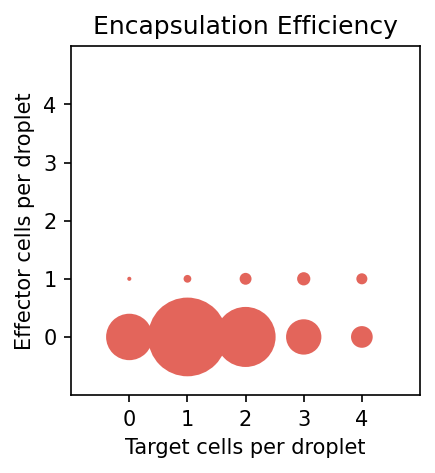

In [8]:
expID = "TECH_XG_009"
droplet_df = prepare_data(RawLoader(expID).get_droplet_df(), 'cell_count_v3')

data = droplet_df.query('outlier == False and frameID == 0').copy() #outlier == False
cols = ['Effector', 'dead_Effector', 'Total_Effector', 
        'Target', 'dead_Target', 'Total_Target']

for col in cols:
    print(f'number of {col.replace("_", " ")}: {sum(data[col])}')

fig, (ax) = plt.subplots(1, 1, figsize=(3, 5), dpi=150)
ax, matrix = get_bubble(data, ax, factor=30)
ax.set_aspect('equal')
ax.set_title("Encapsulation Efficiency")
plt.tight_layout()
plt.show()


### Target viability

outlier
False    72210
True      2938
Name: count, dtype: Int64
outlier
False    3201
Name: count, dtype: Int64


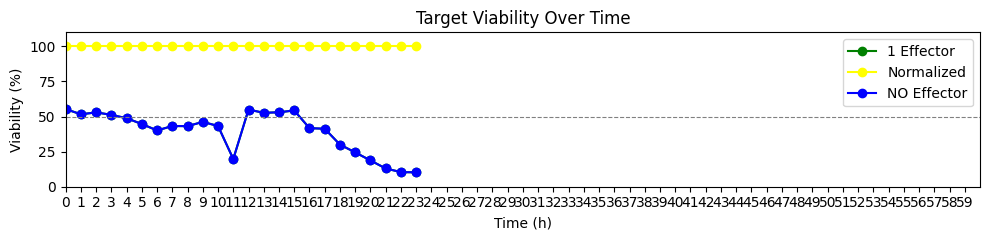

frameID	1 Effector Viability (%)	NO Effector Viability (%)	Normalized Viability (%)
0	55.32	55.32	100.00
1	51.61	51.61	100.00
2	52.94	52.94	100.00
3	51.22	51.22	100.00
4	48.78	48.78	100.00
5	44.68	44.68	100.00
6	40.09	40.09	100.00
7	43.26	43.26	100.00
8	43.16	43.16	100.00
9	46.19	46.19	100.00
10	43.24	43.24	100.00
11	19.73	19.73	100.00
12	54.95	54.95	100.00
13	52.66	52.66	100.00
14	53.05	53.05	100.00
15	54.33	54.33	100.00
16	41.73	41.73	100.00
17	41.32	41.32	100.00
18	30.00	30.00	100.00
19	24.45	24.45	100.00
20	18.73	18.73	100.00
21	13.01	13.01	100.00
22	10.41	10.41	100.00
23	10.26	10.26	100.00


In [10]:

droplet_df = prepare_data(RawLoader(expID).get_droplet_df(), 'cell_count_v3')
print(droplet_df["outlier"].value_counts())

viab_df = droplet_df.query('outlier == False & Total_Target >= 2 & Total_Target <=3 & Total_Effector == 1').copy()
print(viab_df["outlier"].value_counts())

viab_df = viab_df.groupby('frameID')[['dead_Target', 'Total_Target']].sum().reset_index()
viab_df = viab_df.query('frameID <= 60')
viab_df['viability (%)'] = 100 * (1 - viab_df['dead_Target'] / viab_df['Total_Target'])

for _, row in viab_df.iterrows():
    total = row['Total_Target']
    dead = row['dead_Target']
    viability = 100 * (1 - dead / total) if total != 0 else 0
    #print(f"ID {int(row['frameID'])}: {int(dead)} / {int(total)} dead = {viability:.2f}% viability")

norm_df = droplet_df.query('outlier == False & Total_Target >= 2 & Total_Target <=3 & Total_Effector == 1').copy()#outlier == False 
norm_df = norm_df.groupby('frameID')[['dead_Target', 'Total_Target']].sum().reset_index()
norm_df = norm_df.query('frameID <= 60')
norm_df['viability (%)'] = 100 * (1 - norm_df['dead_Target'] / norm_df['Total_Target'])

for _, row in norm_df.iterrows():
    total = row['Total_Target']
    dead = row['dead_Target']
    norm_viability = 100 * (1 - dead / total) if total != 0 else 0

# normalise viab_df with norm_df
viab_df['normalized viability (%)'] = viab_df['viability (%)'] / norm_df['viability (%)'] * 100

# Plot viability
fig, (ax) = plt.subplots(1, 1, figsize=(10, 2.5), dpi=100)
ax.plot(viab_df['frameID'], viab_df['viability (%)'], marker='o', color='green', label='1 Effector')
ax.plot(viab_df['frameID'], viab_df['normalized viability (%)'], marker='o', color='yellow', label='Normalized')
ax.plot(norm_df['frameID'], norm_df['viability (%)'], marker='o', color='blue', label='NO Effector')
ax.set_ylim(0, 110)  # 10% headroom
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)  # Add 50% line
ax.set_xlim(0, 60)
ax.set_xticks(range(60))  # Hour ticks: 0 to 9
ax.set_xlabel("Time (h)")
ax.set_ylabel("Viability (%)")
ax.set_title("Target Viability Over Time")
ax.legend() 
plt.tight_layout()
plt.show()

import pandas as pd

# print all values for 1 Effector and Normalized and NO Effector as table i can copy into excel
print("frameID\t1 Effector Viability (%)\tNO Effector Viability (%)\tNormalized Viability (%)")
for _, row in viab_df.iterrows():
    frameID = int(row['frameID'])
    effector_viability = row['viability (%)']
    normalized_viability = row['normalized viability (%)']
    try:
        no_effector_viability = norm_df.query(f'frameID == {frameID}')['viability (%)'].values[0]
    except IndexError:
        no_effector_viability = 0
    print(f"{frameID}\t{effector_viability:.2f}\t{no_effector_viability:.2f}\t{normalized_viability:.2f}")


### Killing Pies from .csv

In [100]:
# Common filters for ALL conditions
COMMON_QUERY = (
    'outlier == False'
    '& time == 6'
    '& Total_Target >= 2'
    '& Total_Target <= 4'
)

condition_names = {
    '33-4-CAR':         '33-4-CAR_THP1',
    '33-CAR':           '33-CAR_THP1',
    '4-CAR':            '4-CAR_THP1',
    'Mesothelin-CAR':   'Mesothelin-CAR_THP1'
}

# Build the two query dictionaries
conditions = {
    name: f'{COMMON_QUERY} & condition == "{condition}" & Total_Effector == 1'
    for name, condition in condition_names.items()
}

control_condition = {
    name: f'{COMMON_QUERY} & condition == "{condition}" & Total_Effector == 0'
    for name, condition in condition_names.items()
}

33-4-CAR - Effector: mono=0.284, serial=0.227, none=0.4896
33-4-CAR - Control: mono=0.120, serial=0.053, none=0.8273
33-4-CAR - Normalized: mono=0.164, serial=0.174, none=0.6623
33-CAR - Effector: mono=0.233, serial=0.159, none=0.6076
33-CAR - Control: mono=0.138, serial=0.018, none=0.8436
33-CAR - Normalized: mono=0.095, serial=0.141, none=0.7641
4-CAR - Effector: mono=0.295, serial=0.238, none=0.4676
4-CAR - Control: mono=0.146, serial=0.050, none=0.8050
4-CAR - Normalized: mono=0.149, serial=0.188, none=0.6626
Mesothelin-CAR - Effector: mono=0.149, serial=0.010, none=0.8414
Mesothelin-CAR - Control: mono=0.128, serial=0.009, none=0.8627
Mesothelin-CAR - Normalized: mono=0.021, serial=0.000, none=0.9787


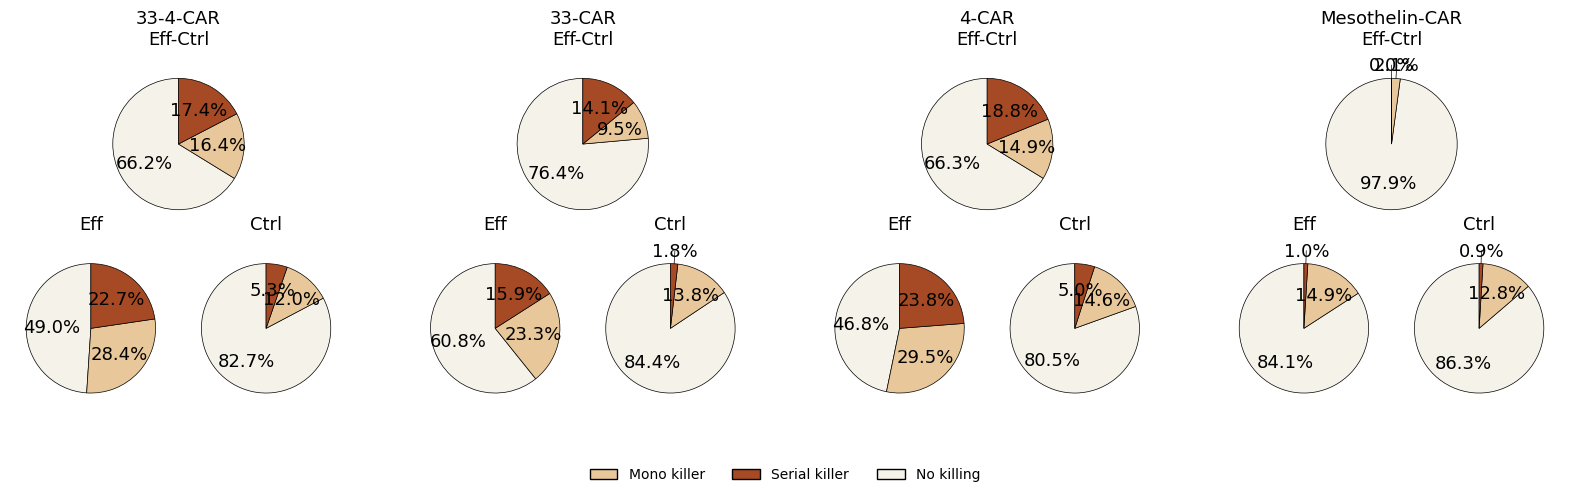

Dataframe lengths for each condition:
33-4-CAR: Effector count = 966, Control count = 1587
33-CAR: Effector count = 734, Control count = 1419
4-CAR: Effector count = 1110, Control count = 1333
Mesothelin-CAR: Effector count = 725, Control count = 1267
Droplets before: 241497


In [101]:
import matplotlib.pyplot as plt
from helpers_pies import draw_pie

fig, axs = plt.subplots(ncols=len(conditions), figsize=(20, 5), sharey=True)
plt.subplots_adjust(bottom=0.15, wspace=0.2)


samples_to_plot = {
    'CARK_JB_035': 'outlier == False'
}

colors = ['#E8C89B','#A54A24','#F5F2E9']
len_dataframes = []


for expID, sample_query in samples_to_plot.items():

    droplet_df = prepare_data(RawLoader(expID).get_droplet_df(),'cell_count_v3')

    for j, (condition_name, query) in enumerate(conditions.items()):

        eff_df = droplet_df.query(query)
        ctrl_df = droplet_df.query(control_condition[condition_name])
        len_dataframes.append((condition_name, len(eff_df), len(ctrl_df)))

        # counts
        mono_eff = eff_df.query('dead_Target == 1').shape[0]
        serial_eff = eff_df.query('dead_Target >= 2').shape[0]

        mono_ctrl = ctrl_df.query('dead_Target == 1').shape[0]
        serial_ctrl = ctrl_df.query('dead_Target >= 2').shape[0]

        eff_total = len(eff_df)
        ctrl_total = len(ctrl_df)


        # percentages
        mono_eff_pct = mono_eff / eff_total if eff_total else 0
        serial_eff_pct = serial_eff / eff_total if eff_total else 0
        mono_ctrl_pct = mono_ctrl / ctrl_total if ctrl_total else 0
        serial_ctrl_pct = serial_ctrl / ctrl_total if ctrl_total else 0

        # raw pies
        eff_values = [mono_eff_pct, serial_eff_pct, max(0, 1 - mono_eff_pct - serial_eff_pct)]
        ctrl_values = [mono_ctrl_pct, serial_ctrl_pct, max(0, 1 - mono_ctrl_pct - serial_ctrl_pct)]

        # normalized pie
        mono_norm = max(0, mono_eff_pct - mono_ctrl_pct)
        serial_norm = max(0, serial_eff_pct - serial_ctrl_pct)
        norm_values = [mono_norm, serial_norm, max(0, 1 - mono_norm - serial_norm)]
        print(f"{condition_name} - Effector: mono={mono_eff_pct:.3f}, serial={serial_eff_pct:.3f}, none={1 - mono_eff_pct - serial_eff_pct:.4f}")
        print(f"{condition_name} - Control: mono={mono_ctrl_pct:.3f}, serial={serial_ctrl_pct:.3f}, none={1 - mono_ctrl_pct - serial_ctrl_pct:.4f}")
        print(f"{condition_name} - Normalized: mono={mono_norm:.3f}, serial={serial_norm:.3f}, none={max(0, 1 - mono_norm - serial_norm):.4f}") 

        # layout
        ax_norm = axs[j].inset_axes([0.25, 0.52, 0.50, 0.45])
        ax_eff_raw = axs[j].inset_axes([0.00, 0.00, 0.48, 0.48])
        ax_ctrl_raw = axs[j].inset_axes([0.52, 0.00, 0.48, 0.48])

        # plot pies
        draw_pie(ax_eff_raw, mono_eff_pct, serial_eff_pct, 'Eff')
        draw_pie(ax_ctrl_raw, mono_ctrl_pct, serial_ctrl_pct, 'Ctrl')
        draw_pie(ax_norm, mono_norm, serial_norm, 'Eff-Ctrl')

        axs[j].set_title(condition_name,fontsize=13,pad=20)
        axs[j].axis('off')


# legend
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=colors[0], edgecolor='black', label='Mono killer'),
    Patch(facecolor=colors[1], edgecolor='black', label='Serial killer'),
    Patch(facecolor=colors[2], edgecolor='black', label='No killing')
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    frameon=False
)
plt.show()

print("Dataframe lengths for each condition:")
for condition_name, eff_len, ctrl_len in len_dataframes:
    print(f"{condition_name}: Effector count = {eff_len}, Control count = {ctrl_len}")
print("Droplets before:", len(droplet_df))